In [1]:
import os
from langchain_groq import ChatGroq

# ✅ Correct way to read environment variables
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# ✅ Correct model initialization
model = ChatGroq(
    model_name="qwen/qwen3-32b"
)

In [6]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general",)
tavily_search_tool.invoke("What is the current ai news")

{'query': 'What is the current ai news',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.wsj.com/tech/ai?gaa_at=eafs&gaa_n=AWEtsqc9S3Hdu1mmOa96H5d61Fm2EZYFFyWKebO0EZ61f6J5mDiIWP72Qzx9&gaa_ts=69a2df56&gaa_sig=kTpB1CB0K6d9YsCnCQo3OTZNwTHmH00bnvKVvw5VgTSc1av76oXPx5zV-cAMmOZtK_d2P9BC2667BzEb02jHVA%3D%3D',
   'title': 'Artificial Intelligence - Latest AI News and Analysis - WSJ.com',
   'content': 'The latest artificial intelligence news coverage focusing on the technology, tools and the companies building AI technology.',
   'score': 0.9989267,
   'raw_content': None},
  {'url': 'https://www.artificialintelligence-news.com/',
   'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
   'content': 'AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide.',
   'score': 0.9985104,
   'raw_content': None},
  {'url': 'https://www.reuters.co

In [4]:
from langchain.tools import tool
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [5]:
tool

<function langchain_core.tools.convert.tool(name_or_callable: str | collections.abc.Callable | None = None, runnable: langchain_core.runnables.base.Runnable | None = None, *args: Any, description: str | None = None, return_direct: bool = False, args_schema: type[pydantic.main.BaseModel] | dict[str, typing.Any] | None = None, infer_schema: bool = True, response_format: Literal['content', 'content_and_artifact'] = 'content', parse_docstring: bool = False, error_on_invalid_docstring: bool = True, extras: dict[str, typing.Any] | None = None) -> langchain_core.tools.base.BaseTool | collections.abc.Callable[[collections.abc.Callable | langchain_core.runnables.base.Runnable], langchain_core.tools.base.BaseTool]>

In [8]:
from langchain.agents import create_agent
agent = create_agent( model,
    [tavily_search_tool,calc]
)

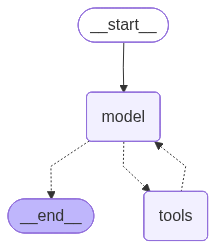

In [9]:
agent

In [13]:
user_input = "What is the current AI new for Anthropic and then calculate 5+5"
for step in agent.stream(
    {"messages":user_input},
    stream_mode = "values"
):
   step["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current AI new for Anthropic and then calculate 5+5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (0k1s7bzxv)
 Call ID: 0k1s7bzxv
  Args:
    query: current AI news for Anthropic
    topic: news
  calculator (1zw2463y3)
 Call ID: 1zw2463y3
  Args:
    expression: 5+5
================================= Tool Message =================================
Name: calculator

10
================================== Ai Message ==================================

**Current AI News for Anthropic:**
1. Anthropic announced new enterprise AI offerings, competing with Google's recent AI capabilities.
2. The company is facing pressure from the U.S. Defense Department to modify its AI policies, creating a "lose-lose situation."
3. Anthropic's leadership emphasized rejecting demands that would compromise user trust or enable harmful AI applications.
4. Re

In [15]:
agent.invoke({"messages":"What is the current ai news"})

{'messages': [HumanMessage(content='What is the current ai news', additional_kwargs={}, response_metadata={}, id='b812d454-4d27-4f6d-b4b5-4ef05bbbd37a'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the current AI news. I need to figure out which tool to use here. The available tools are tavily_search and calculator. Since the user is asking for news, the calculator isn\'t relevant here. So I should use tavily_search.\n\nNow, looking at the parameters for tavily_search. The query is "current ai news". The user wants the latest information, so I should consider the time_range parameter. The time_range options are day, week, month, year. The user didn\'t specify a time frame, but "current" usually implies recent news. Maybe "week" would be a good start to get the latest updates.\n\nAlso, the topic parameter. The user is asking about AI news. The topic options are general, news, finance. Since it\'s about current events, "news" might be app